GA1-RA1_spikes.mat
  n_detected=1902, waveform_len=74
  sr=32000.0 Hz, duration=7984.0 s
  timestamps_start=1711139561.8595219
  spike times (s): 5.071 – 7981.896

times_GA1-RA1.mat
  n_sorted=1887, unique clusters=[0 1]
    cluster 0: 57 spikes
    cluster 1: 1830 spikes
  rejected flags: 15 / 1902

GA1-RA1_spikeCodes.mat
  spikeHist: 2661322 bins @ ~3.00 ms, 2851 active bins


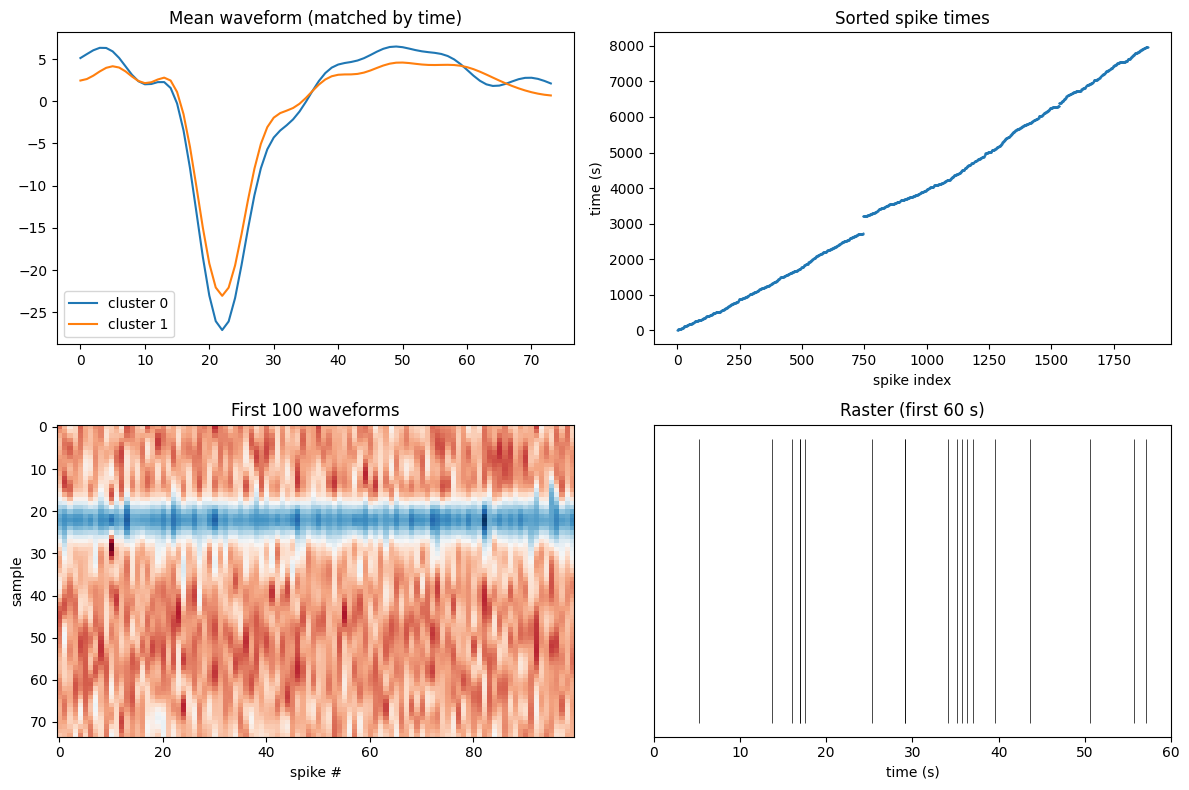

In [1]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path(
    "/store/scratch/bsow/Documents/UCLA_24/data/ucla_data/572/"
    "Experiment-8-9-10-11/CSC_micro_spikes_removePLI-0_CAR-1_rejectNoiseSpikes-1"
)
CHANNEL = "GA1-RA1"

spikes_mat = DATA_DIR / f"{CHANNEL}_spikes.mat"
codes_mat = DATA_DIR / f"{CHANNEL}_spikeCodes.mat"
times_mat = DATA_DIR / f"times_{CHANNEL}.mat"

# --- spikes.mat ---
with h5py.File(spikes_mat, "r") as f:
    waveforms = f["spikes"][()]          # (74, n_detected)
    spike_times_s = f["spikeTimestamps"][()].ravel()
    timestamps_start = float(f["timestampsStart"][0, 0])  # Unix-ish session anchor
    sr = float(f["param/sr"][0, 0])
    duration_s = float(f["duration"][0, 0])

print(f"{CHANNEL}_spikes.mat")
print(f"  n_detected={waveforms.shape[1]}, waveform_len={waveforms.shape[0]}")
print(f"  sr={sr} Hz, duration={duration_s:.1f} s")
print(f"  timestamps_start={timestamps_start}")
print(f"  spike times (s): {spike_times_s.min():.3f} – {spike_times_s.max():.3f}")

# --- times.mat (sorted / classified spikes) ---
with h5py.File(times_mat, "r") as f:
    cluster_ids = f["cluster_class"][0, :].astype(int)
    sorted_times_s = f["cluster_class"][1, :].ravel()
    rejected = f["spikeIdxRejected"][()].astype(bool).ravel()

print(f"\ntimes_{CHANNEL}.mat")
print(f"  n_sorted={sorted_times_s.size}, unique clusters={np.unique(cluster_ids)}")
for cid in np.unique(cluster_ids):
    print(f"    cluster {cid}: {(cluster_ids == cid).sum()} spikes")
print(f"  rejected flags: {rejected.sum()} / {rejected.size}")

# --- spikeCodes.mat (binned raster) ---
with h5py.File(codes_mat, "r") as f:
  spike_hist = f["spikeHist"][()].ravel().astype(np.uint8)
  # spikeCodes is a MATLAB table; raw HDF5 value is an object reference, not useful in Python without mat73

bin_ms = duration_s * 1000.0 / spike_hist.size
print(f"\n{CHANNEL}_spikeCodes.mat")
print(f"  spikeHist: {spike_hist.size} bins @ ~{bin_ms:.2f} ms, {spike_hist.sum()} active bins")

# Quick plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Mean waveforms per cluster (from times file)
for cid in np.unique(cluster_ids):
    idx = cluster_ids == cid
    # match sorted spike times to detected waveforms by timestamp
    t_clu = sorted_times_s[idx]
    cols = [np.argmin(np.abs(spike_times_s - t)) for t in t_clu[:200]]  # subsample for speed
    mean_wf = waveforms[:, cols].mean(axis=1)
    axes[0, 0].plot(mean_wf, label=f"cluster {cid}")
axes[0, 0].set_title("Mean waveform (matched by time)")
axes[0, 0].legend()

axes[0, 1].plot(sorted_times_s, ".", ms=1)
axes[0, 1].set_xlabel("spike index")
axes[0, 1].set_ylabel("time (s)")
axes[0, 1].set_title("Sorted spike times")

axes[1, 0].imshow(waveforms[:, :100], aspect="auto", cmap="RdBu_r")
axes[1, 0].set_title("First 100 waveforms")
axes[1, 0].set_xlabel("spike #")
axes[1, 0].set_ylabel("sample")

win_s = 60.0
t0 = sorted_times_s.min()
mask = (sorted_times_s >= t0) & (sorted_times_s < t0 + win_s)
axes[1, 1].vlines(sorted_times_s[mask] - t0, 0, 1, color="k", linewidth=0.5)
axes[1, 1].set_xlim(0, win_s)
axes[1, 1].set_title(f"Raster (first {win_s:.0f} s)")
axes[1, 1].set_xlabel("time (s)")
axes[1, 1].set_yticks([])

plt.tight_layout()
plt.show()

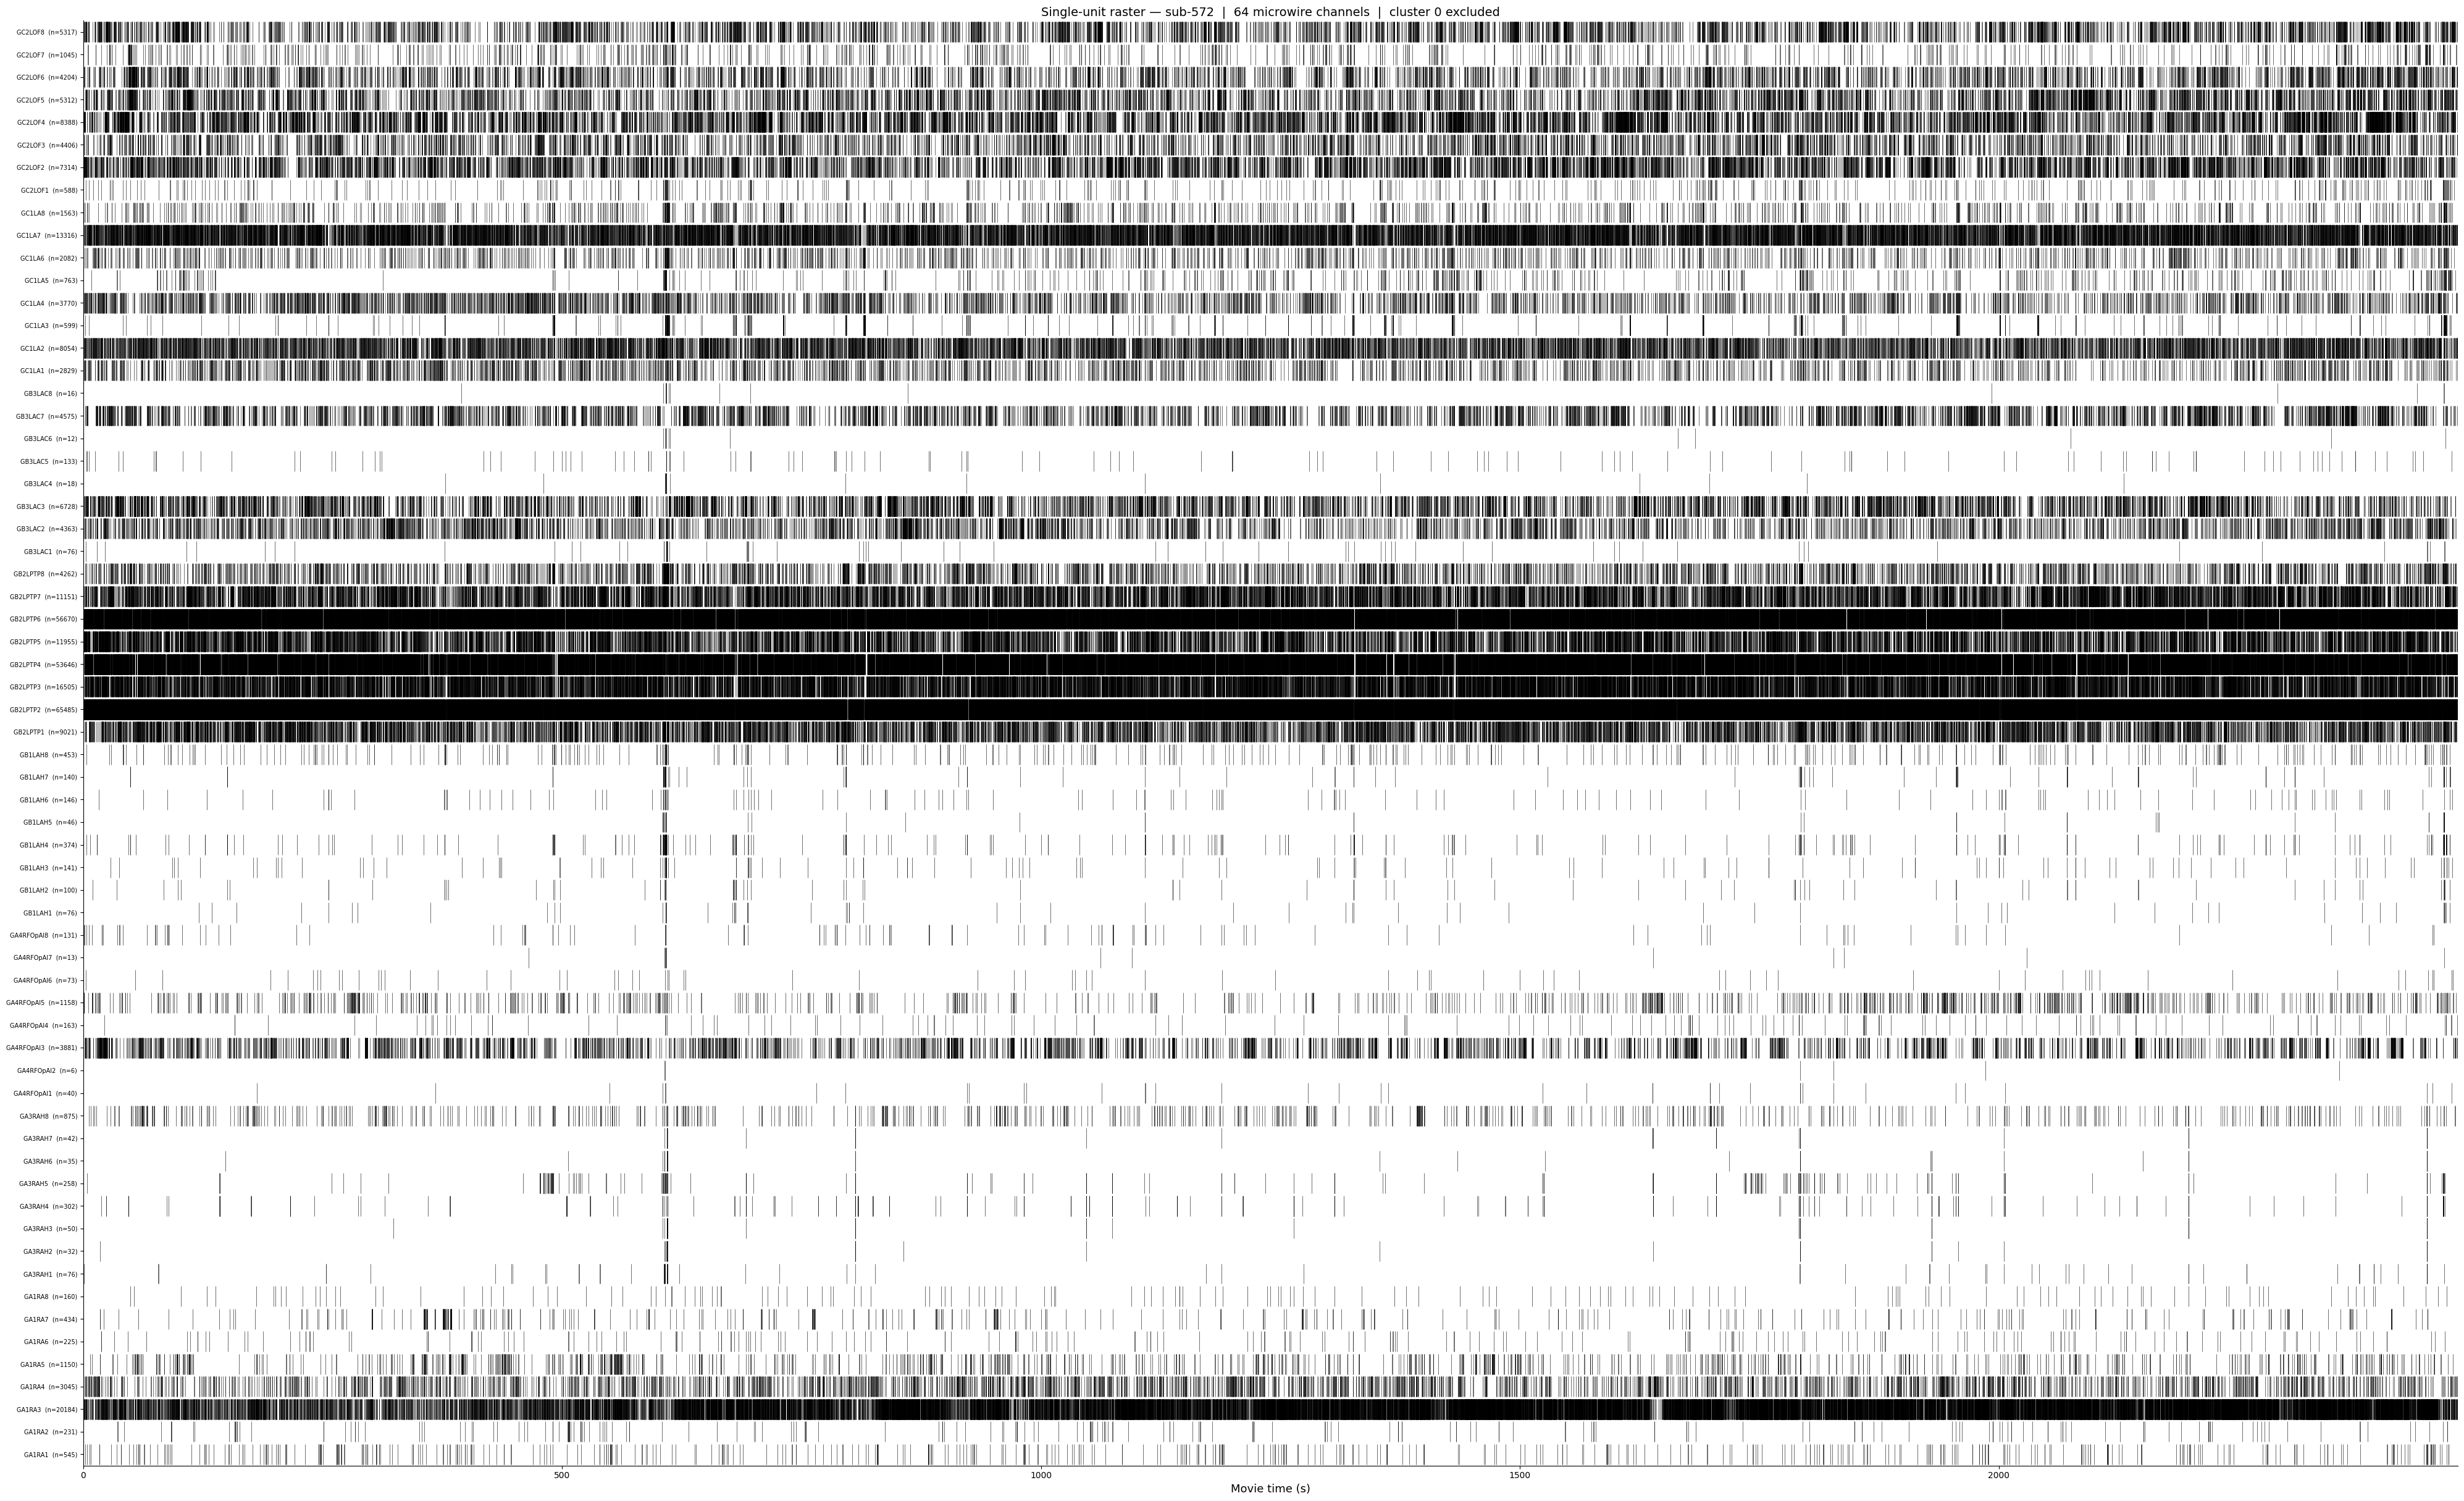

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

NPZ_DIR = Path("/store/scratch/bsow/Documents/UCLA_24/data/bids/derivatives/spike-sorted/sub-572/ses-01/ieeg")

# Load all channels, sorted units only (cluster_id >= 1)
npz_files = sorted(NPZ_DIR.glob("*spikedata.npz"))

channels = []
spike_trains = []   # list of spike time arrays (movie time, seconds)

for p in npz_files:
    d = np.load(p, allow_pickle=True)
    ch = str(d["channel"])
    times = d["spike_times_movie"].astype(np.float64)
    cids  = d["cluster_id"]
    valid = times[cids >= 1]
    channels.append(ch)
    spike_trains.append(valid)

movie_duration = float(np.load(npz_files[0], allow_pickle=True)["movie_duration_sec"])
n_ch = len(channels)

# ── Figure ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(40, n_ch * 0.35 + 2))

for i, (ch, spikes) in enumerate(zip(channels, spike_trains)):
    ax.vlines(spikes, i + 0.05, i + 0.95, linewidth=0.4, color="black")

ax.set_xlim(0, movie_duration)
ax.set_ylim(0, n_ch)
ax.set_yticks(np.arange(n_ch) + 0.5)
ax.set_yticklabels(
    [f"{ch}  (n={len(st)})" for ch, st in zip(channels, spike_trains)],
    fontsize=7,
)
ax.set_xlabel("Movie time (s)", fontsize=13)
ax.set_title(
    f"Single-unit raster — sub-572  |  {n_ch} microwire channels  |  cluster 0 excluded",
    fontsize=14,
)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
